Tests d'invariance

In [1]:
import numpy as np
import pandas as pd
import joblib

# Chargement du dictionnaire sauvegardé par Kedro
model_dict = joblib.load("../data/06_model/model.pkl")
model = model_dict["model"]

# Chargement des données
X_test = pd.read_csv("../data/05_model_input/X_test.csv")
y_test = pd.read_csv("../data/05_model_input/y_test.csv").values.flatten()
print("OK modèle et données chargés")
print("Shape X_test:", X_test.shape)
print("Shape y_test:", y_test.shape)
print(type(model_dict))
print(model_dict.keys())


OK modèle et données chargés
Shape X_test: (6892, 13)
Shape y_test: (6892,)
<class 'dict'>
dict_keys(['model', 'name', 'params', 'score'])


In [2]:
# Test d'invariance sur une observation
x_unit = X_test.loc[4720, :].copy()
print("Pos : {:2.3f}%".format(model.predict_proba([x_unit])[0, 1] * 100))


c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Pos : 94.540%


In [3]:
x_unit_1 = X_test.loc[4720, :].copy()
x_unit_1['price'] = x_unit_1['price'] + 1
print('Pos : {:2.3f}%'.format(model.predict_proba([x_unit_1])[0, 1] * 100))
x_unit_1 = X_test.loc[4720, :].copy()
x_unit_1['price'] = x_unit_1['price'] - 1
print('Pos : {:2.3f}%'.format(model.predict_proba([x_unit_1])[0, 1] * 100))


Pos : 94.540%
Pos : 94.540%


c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [4]:
X_test_price = X_test[X_test['price'] > 1]
X_test_price_plus = X_test_price.copy()
# On ne sélectionne que les articles dont le prix est > à 1€, sinon on aurait un prix ... négatif !
X_test_price_plus['price'] = X_test_price_plus['price'] + 1
X_test_price_minus = X_test_price.copy()
X_test_price_minus['price'] = X_test_price_minus['price'] - 1
y_price = pd.DataFrame()
y_price['y'] = model.predict_proba(X_test_price)[:, 1]
y_price['y+'] = model.predict_proba(X_test_price_plus)[:, 1]
y_price['y-'] = model.predict_proba(X_test_price_minus)[:, 1]
y_price['abs_delta'] = np.abs(y_price['y-'] - y_price['y+'])
y_price.sort_values('abs_delta', ascending=False).head(n=10)

,y,y+,y-,abs_delta
1807,0.335061,0.335061,0.654649,0.319588
6784,0.230237,0.230237,0.548007,0.317770
4698,0.344729,0.344729,0.587330,0.242601
1342,0.323898,0.560120,0.323898,0.236222
6081,0.674118,0.448678,0.674118,0.225440
2508,0.608867,0.608867,0.828496,0.219629
2330,0.441724,0.231577,0.441724,0.210147
3293,0.675857,0.467097,0.675857,0.208760
1853,0.643221,0.434618,0.643221,0.208603
6688,0.735936,0.528902,0.735936,0.207034


In [5]:
idxs = list(y_price.sort_values("abs_delta", ascending=False).head(n=100).index)
X_test_price.loc[idxs, :]

,product_id,brand,price,num_views_session,num_views_product,category,sub_category,hour,minute,weekday,duration,num_prev_sessions,num_prev_product_views
1807,12706780,442,41.44,1,1,13,41,6,18,1,38,0,0
6784,5300172,477,56.60,3,3,13,41,3,14,1,185,0,0
4698,11400268,668,21.09,2,2,13,41,18,12,1,60,0,0
1342,3700779,668,299.88,3,3,2,16,13,41,1,2420,1,1
6081,12703493,131,40.41,24,3,13,41,11,15,1,988,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,1002544,30,464.13,4,2,7,29,2,29,1,180,0,0
737,1004767,543,254.11,6,4,7,29,15,22,1,359,0,0
880,1002544,30,464.08,6,5,7,29,3,49,1,161,0,0
4229,1004767,543,254.11,7,5,7,29,16,27,1,391,0,0


In [8]:
import shap

explainer = shap.TreeExplainer(model)
X_shap = X_test_price.copy()
# On calcul ici les valeurs de Shapley
shap_values = explainer.shap_values(X_shap)

c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [10]:
shap_values

array([[-0.52594529, -0.1191596 ,  0.07789612, ..., -0.44454967,
        -0.09292997,  0.00724662],
       [-0.25823784, -0.4191595 , -0.22655864, ..., -0.4018619 ,
         0.53637807, -0.0761337 ],
       [-0.02967219,  0.77242047,  0.46588229, ...,  0.58668383,
        -0.09309038,  0.006101  ],
       ...,
       [-0.7831494 , -0.00212017, -0.09589193, ...,  0.5223821 ,
        -0.15886609,  0.00446866],
       [ 0.46700897,  0.16300731,  0.51371491, ...,  0.23787723,
        -0.0506839 ,  0.00471051],
       [-0.06878478, -0.09718765, -0.04717223, ..., -0.38509333,
         0.77062384,  0.05452555]], shape=(6891, 13))

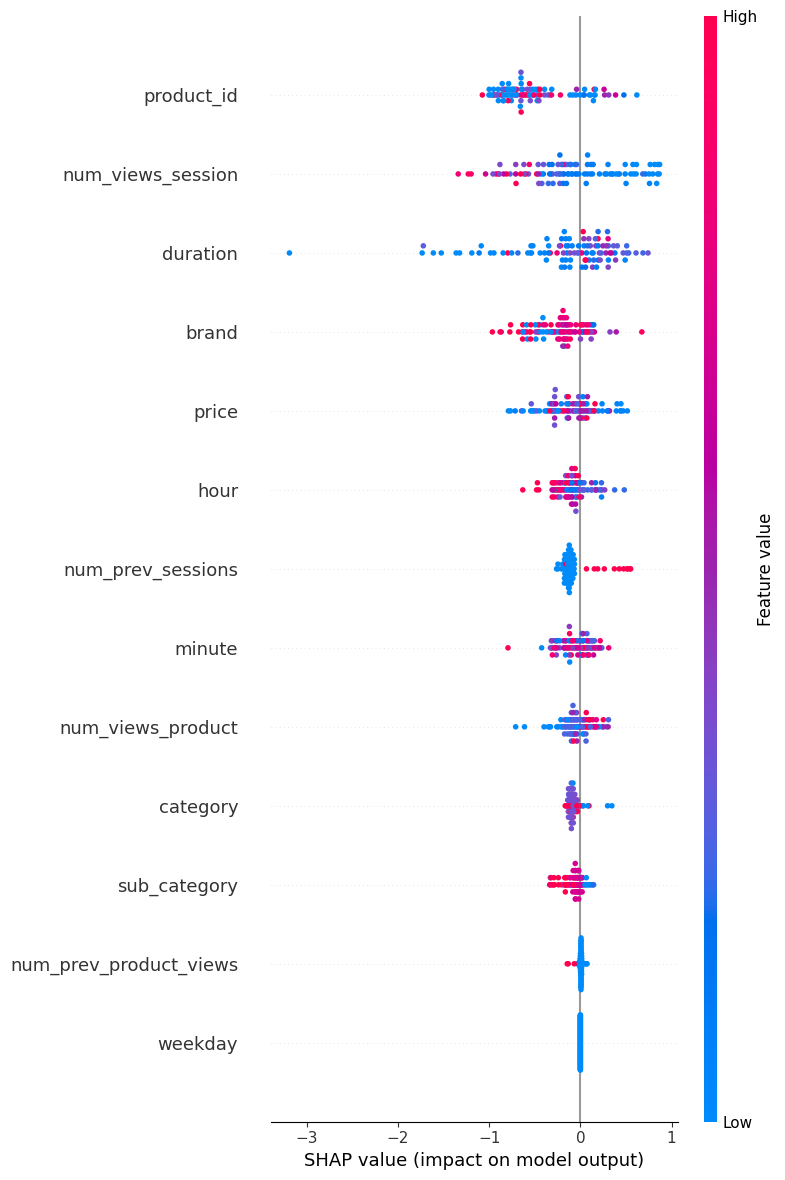

In [11]:
shap.summary_plot(shap_values[idxs, :], X_shap.loc[idxs, :], plot_size=0.8)

In [12]:
print("Écart-type : {:2.2f}%".format(y_price["abs_delta"].std()))
print("Proportion : {:2.2f}%".format(
    y_price[y_price["abs_delta"] < 0.05].shape[0] / y_price.shape[0] * 100
))

Écart-type : 0.02%
Proportion : 93.41%


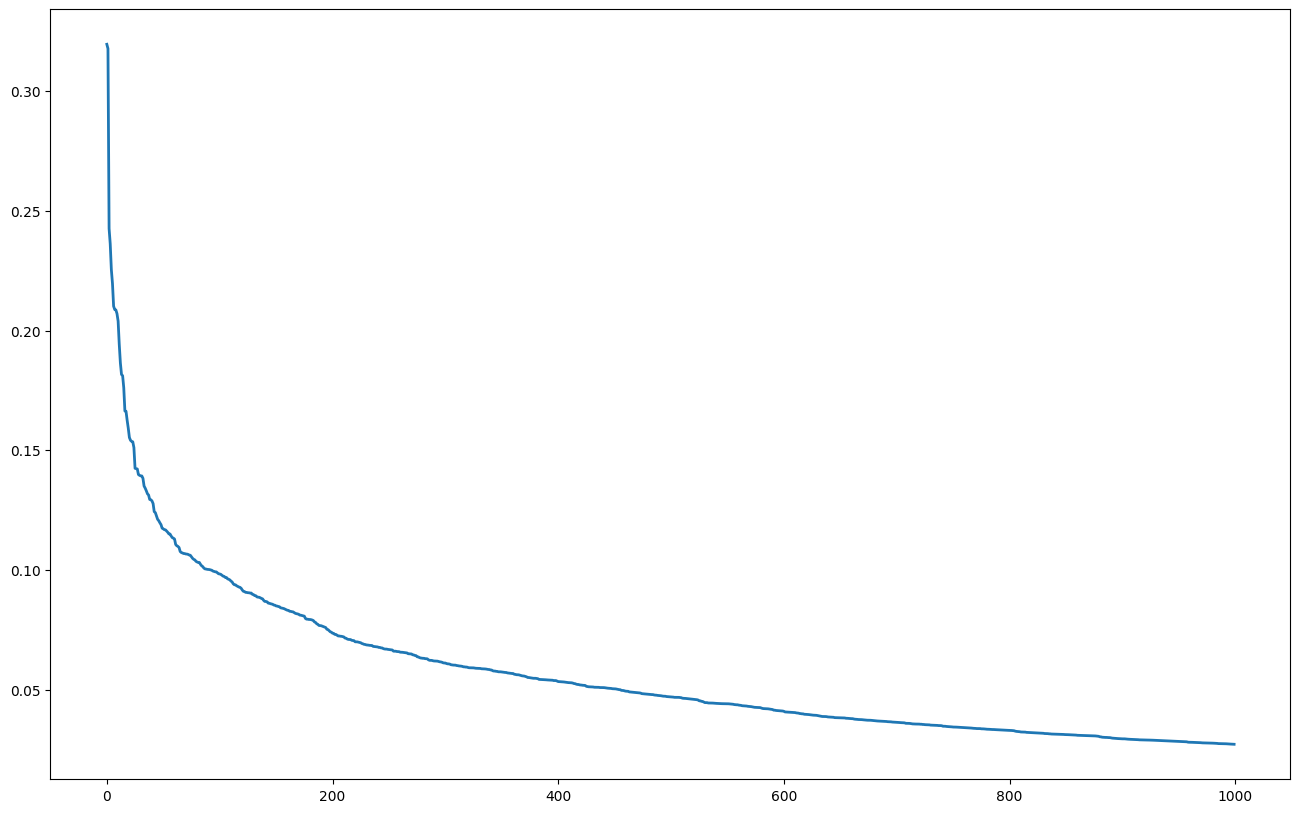

In [13]:
import matplotlib.pyplot as plt

n_obs = 1000

plt.figure(figsize=(16,10))
plt.plot(
    range(n_obs),
    y_price.sort_values("abs_delta", ascending=False).iloc[:n_obs, -1],
    lw=2
)

Tests directionnels

In [14]:
x_unit_2 = X_test.loc[375, :]
model.predict_proba([x_unit_2])

c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[0.91115062, 0.08884938]])

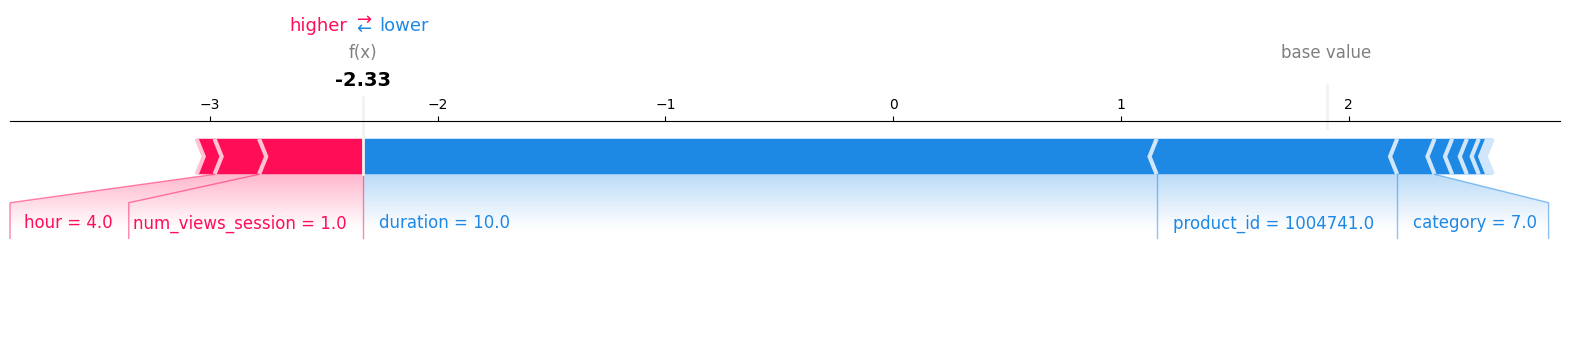

In [15]:
shap.force_plot(explainer.expected_value, shap_values[375, :], x_unit_2, matplotlib=True)

In [16]:
x_unit_3 = X_test.iloc[375, :].copy()
x_unit_3['duration'] = x_unit_3['duration'] + 60
model.predict_proba([x_unit_3])

c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[0.21826179, 0.78173821]])

In [17]:
X_test.iloc[375, :]

product_id                1004741.00
brand                         668.00
price                         185.71
num_views_session               1.00
num_views_product               1.00
category                        7.00
sub_category                   29.00
hour                            4.00
minute                         50.00
weekday                         1.00
duration                       10.00
num_prev_sessions               0.00
num_prev_product_views          0.00
Name: 375, dtype: float64

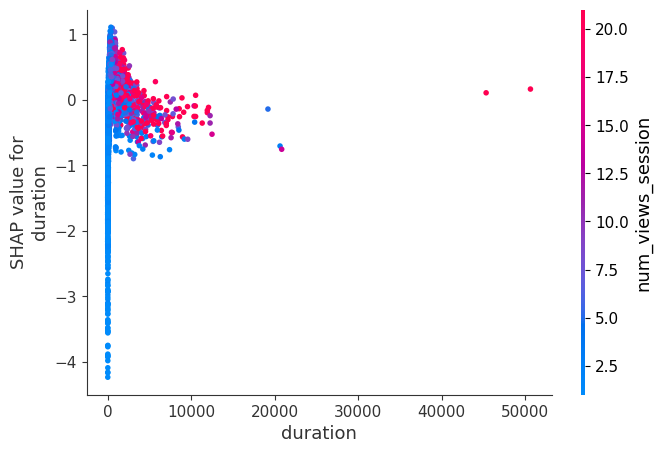

In [18]:
shap.dependence_plot("duration", shap_values, X_shap)

In [19]:
x_unit_4 = X_test.iloc[375, :].copy()
x_unit_4['duration'] = x_unit_4['duration'] + 10
x_unit_4['num_views_session'] = x_unit_4['num_views_session'] + 10
model.predict_proba([x_unit_4])

c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[0.8634511, 0.1365489]])

In [20]:
x_unit_5 = X_test.loc[4720, :]
model.predict_proba([x_unit_5])

c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[0.05459628, 0.94540372]])

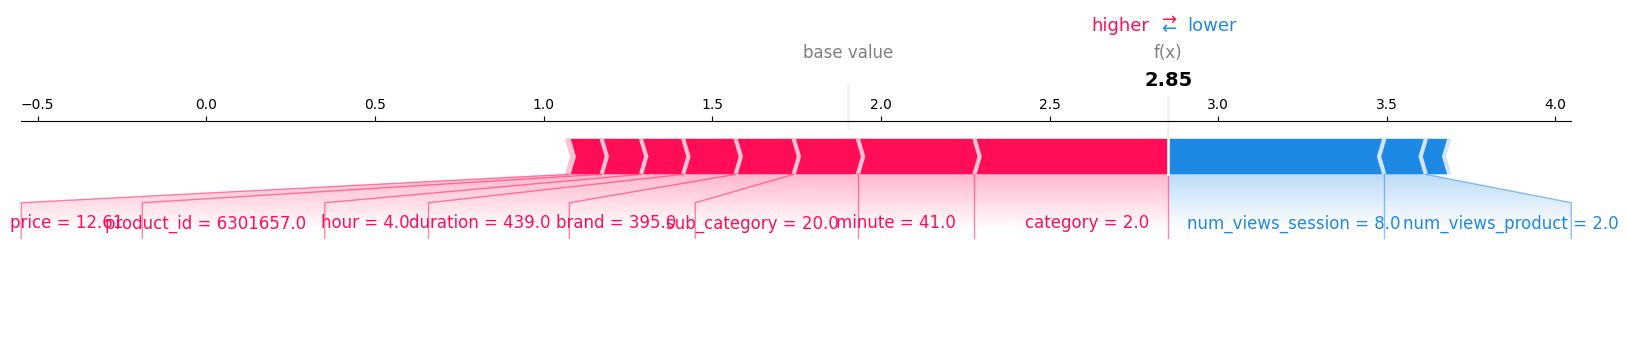

In [21]:
shap.force_plot(explainer.expected_value, shap_values[4720, :], x_unit_5, matplotlib=True)

In [22]:
x_unit_6 = X_test.loc[4720, :].copy()
x_unit_6['duration'] = x_unit_6['duration'] - 60
model.predict_proba([x_unit_6])

c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[0.04064418, 0.95935582]])

Tests unitaires du modèle

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=30)
clusters = kmeans.fit_predict(X_test)
centroids = kmeans.cluster_centers_   

In [24]:
X_prototypes = pd.DataFrame(
    data=centroids,
    columns=X_test.columns
)
X_prototypes

,product_id,brand,price,num_views_session,num_views_product,category,sub_category,hour,minute,weekday,duration,num_prev_sessions,num_prev_product_views
0,1.682868e+07,442.278571,129.051071,7.939286,2.632143,10.750000,34.821429,10.107143,28.500000,1.0,739.592857,0.260714,0.071429
1,1.069468e+06,345.421795,484.339572,5.657436,2.534872,6.871538,29.429744,10.455641,29.540256,1.0,530.760000,0.252308,0.116667
2,2.907624e+07,462.442478,95.703363,9.274336,2.752212,6.353982,31.858407,11.141593,31.274336,1.0,720.823009,0.230088,0.070796
3,1.186016e+07,411.619850,90.015318,6.574906,2.580524,10.520599,35.170412,10.295880,29.915730,1.0,674.398876,0.170412,0.067416
4,5.377111e+06,368.636450,134.886966,6.166985,2.645038,7.452290,14.174618,10.588740,28.779580,1.0,583.352099,0.260496,0.134542
5,4.291188e+07,423.823529,144.332941,11.000000,2.764706,10.294118,35.176471,10.205882,26.323529,1.0,695.264706,0.117647,0.058824
6,3.514224e+07,442.558140,92.943721,16.837209,2.860465,11.837209,39.674419,11.581395,34.720930,1.0,1208.651163,0.209302,0.023256
7,2.218875e+07,423.302521,90.246134,7.689076,2.882353,10.739496,29.865546,10.840336,28.563025,1.0,570.310924,0.193277,0.042017
8,3.418928e+06,368.648506,188.261318,7.244288,2.792619,3.908612,22.551845,9.833040,29.680141,1.0,651.752197,0.170475,0.066784
9,2.626479e+07,511.980159,217.815000,7.849206,2.591270,12.837302,40.626984,10.535714,28.507937,1.0,607.813492,0.202381,0.019841


In [25]:
model.predict_proba(centroids)

c:\Users\eyala\Documents\Cytech\ING3 GIA\MLOps\mlops_cours\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[0.06813759, 0.93186241],
       [0.0309155 , 0.9690845 ],
       [0.04557265, 0.95442735],
       [0.20930884, 0.79069116],
       [0.06566766, 0.93433234],
       [0.02068781, 0.97931219],
       [0.03208545, 0.96791455],
       [0.08907901, 0.91092099],
       [0.12248279, 0.87751721],
       [0.00227594, 0.99772406]])